Convolutional Neural Network(CNN) Model for Brain tumor Detection

In [2]:
!pip install split-folders
!pip install torch-summary

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Importing Essential Libraries

In [3]:
# Import essential libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(style='darkgrid')
import copy # A module that provides functions for creating copies of objects, useful for avoiding unintended modifications to variables.
import os # A module that provides a way to interact with the operating system, allowing for tasks such as file and directory manipulation.
import torch
from PIL import Image # A module from the Python Imaging Library (PIL) that provides functionality for opening, manipulating, and saving various image file formats.
from torch.utils.data import Dataset # A PyTorch class that represents a dataset and provides an interface for accessing and processing the data during training.
import torchvision
import torchvision.transforms as transforms # A module from the torchvision library that provides common image transformations, such as resizing, cropping, and normalization.
from torch.utils.data import random_split # A function from PyTorch that allows for randomly splitting a dataset into training and validation subsets.
from torch.optim.lr_scheduler import ReduceLROnPlateau # A PyTorch scheduler that adjusts the learning rate during training based on a specified metric, reducing it when the metric plateaus.
import torch.nn as nn # A module in PyTorch that provides classes for defining and building neural networks.
from torchvision import utils # A module from torchvision that contains utility functions for working with images, such as saving and visualizing them.
from torchvision.datasets import ImageFolder
import splitfolders
from torchsummary import summary
import torch.nn.functional as F
import pathlib
from sklearn.metrics import confusion_matrix, classification_report
import itertools # This import statement imports the itertools module, which provides functions for efficient looping and combining of iterables. It can be used for tasks such as generating combinations or permutations of elements.
from tqdm.notebook import trange, tqdm # These functions allow for the creation of progress bars to track the progress of loops or tasks.
from torch import optim
import warnings
warnings.filterwarnings('ignore')

Feature Extraction using Resnet18

In [4]:
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()  # Remove the classification layer for feature extraction
        self.fc = nn.Linear(512, num_classes)  # New classification layer
    
    def forward(self, x, extract_features=False):
        features = self.resnet(x)
        if extract_features:
            return features  # Return only features if extraction is required
        return self.fc(features)

In [5]:
labels_df = pd.read_csv('C:/Users/sures/Downloads/Brain_Tumor/metadata.csv')
print(labels_df.head().to_markdown())

|    |   Unnamed: 0 | image           | class   | format   | mode   | shape         |
|---:|-------------:|:----------------|:--------|:---------|:-------|:--------------|
|  0 |            0 | Cancer (1).jpg  | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  1 |            1 | Cancer (1).png  | tumor   | PNG      | L      | (300, 240)    |
|  2 |            2 | Cancer (1).tif  | tumor   | TIFF     | RGB    | (256, 256, 3) |
|  3 |            3 | Cancer (10).jpg | tumor   | JPEG     | RGB    | (512, 512, 3) |
|  4 |            4 | Cancer (10).tif | tumor   | TIFF     | RGB    | (256, 256, 3) |


In [6]:
import os
print(os.listdir('C:/Users/sures/Downloads/Brain_Tumor/Brain Tumor Data Set'))

['Brain Tumor', 'Healthy']


In [7]:
labels_df.shape

(4600, 6)

Splitting Dataset to Train_set,Val_set,Test_set

In [8]:
# Dataset Path
data_dir = 'C:/Users/sures/Downloads/Brain_Tumor/Brain Tumor Data Set'
data_dir = pathlib.Path(data_dir)
# Splitting dataset to train_set, val_set and test_set
splitfolders.ratio(data_dir, output='brain', seed=20, ratio=(0.8, 0.2))
# New dataset path
data_dir = '/kaggle/working/brain'
data_dir = pathlib.Path(data_dir)

Copying files: 797 files [00:03, 206.26 files/s]


Transformation

In [9]:
# define transformation
transform = transforms.Compose(
    [
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(30),
        transforms.ToTensor(),
        transforms.Normalize(mean = [0.485, 0.456, 0.406],std = [0.229, 0.224, 0.225])
   ]
)

In [10]:
import os
from pathlib import Path
data_dir = Path("C:/Users/sures/Downloads/Brain_Tumor/Brain Tumor Data Set")
if data_dir.exists():
    print("Directory exists:", data_dir)
    print("Subfolders:", os.listdir(data_dir))  # List the dataset folders
else:
    print("Error: The specified dataset directory does not exist!")


Directory exists: C:\Users\sures\Downloads\Brain_Tumor\Brain Tumor Data Set
Subfolders: ['Brain Tumor', 'Healthy']


In [11]:
data_dir = Path("C:/Users/sures/Downloads/Brain_Tumor/brain")

train_dir = data_dir / "train"
val_dir = data_dir / "val"

train_set = torchvision.datasets.ImageFolder(str(train_dir), transform=transform)
val_set = torchvision.datasets.ImageFolder(str(val_dir), transform=transform)


Visualization of Train set Images

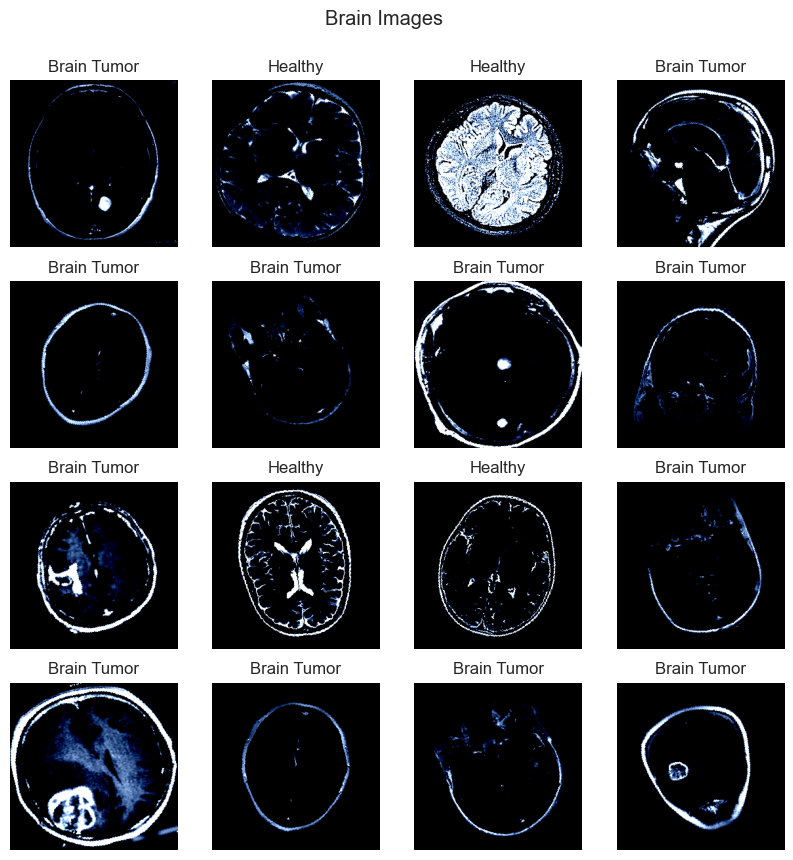

In [12]:
# Visualiztion some images from Train Set
CLA_label = {
    0 : 'Brain Tumor',
    1 : 'Healthy'
} 
figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_set), size=(1,)).item()
    img, label = train_set[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(CLA_label[label])
    plt.axis("off")
    img_np = img.numpy().transpose((1, 2, 0))
    # Clip pixel values to [0, 1]
    img_valid_range = np.clip(img_np, 0, 1)
    plt.imshow(img_valid_range)
    plt.suptitle('Brain Images', y=0.95)
plt.show()

Creating Dataloaders

In [13]:
# import and load train, validation
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle = True, num_workers = 2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle = True, num_workers = 2)


Shape of Training data and Validation Data

In [14]:
# print shape for Training data and Validation data
for key, value in {'Training data': train_loader, "Validation data": val_loader}.items():
    for X, y in value:
        print(f"{key}:")
        print(f"Shape of X : {X.shape}")
        print(f"Shape of y: {y.shape} {y.dtype}\n")
        break

Training data:
Shape of X : torch.Size([64, 3, 256, 256])
Shape of y: torch.Size([64]) torch.int64

Validation data:
Shape of X : torch.Size([64, 3, 256, 256])
Shape of y: torch.Size([64]) torch.int64



Filtering Noise

In [15]:
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import os
from pathlib import Path
def is_valid_image(image_path):
    """Check if an image is valid and not corrupted."""
    try:
        with Image.open(image_path) as img:
            img.verify()
        return True
    except Exception:
        return False
def apply_noise_filter(image_path):
    """Apply noise reduction using Gaussian Blur and edge detection."""
    image = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if image is None:
        return False  # Image is unreadable
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Apply Canny edge detection
    edges = cv2.Canny(blurred, threshold1=30, threshold2=100)
    # Calculate edge density
    edge_density = np.mean(edges) / 255
    # Remove overly noisy or overly smooth images
    if edge_density < 0.02 or edge_density > 0.8:
        return False
    return True
def clean_dataset(data_dir):
    """Filter out noisy or invalid images from the dataset."""
    data_dir = Path(data_dir)
    for category in data_dir.iterdir():  # Iterate over class folders
        if category.is_dir():
            for image_path in category.iterdir():
                if image_path.suffix.lower() in ['.jpg', '.png', '.jpeg']:
                    if not is_valid_image(image_path) or not apply_noise_filter(str(image_path)):
                        print(f"Removing: {image_path}")
                        os.remove(image_path)
# Run noise filtering on your dataset directory
data_dir = "C:/Users/sures/Downloads/Brain_Tumor/Brain Tumor Data Set"
clean_dataset(data_dir)


How many images are there Before and After filtering of noise

In [16]:
import os
def count_images(data_dir):
    total_images = 0
    for category in os.listdir(data_dir):
        category_path = os.path.join(data_dir, category)
        if os.path.isdir(category_path):
            num_images = len([img for img in os.listdir(category_path) if img.lower().endswith(('.jpg', '.png', '.jpeg'))])
            print(f"{category}: {num_images} images")
            total_images += num_images
    print(f"Total images: {total_images}")
# Before filtering
print("Before filtering:")
count_images("C:/Users/sures/Downloads/Brain_Tumor/Brain Tumor Data Set")
# After filtering
print("\nAfter filtering:")
count_images("C:/Users/sures/Downloads/Brain_Tumor/Brain Tumor Data Set")

Before filtering:
Brain Tumor: 372 images
Healthy: 398 images
Total images: 770

After filtering:
Brain Tumor: 372 images
Healthy: 398 images
Total images: 770


Visualization of images after the noise filtering

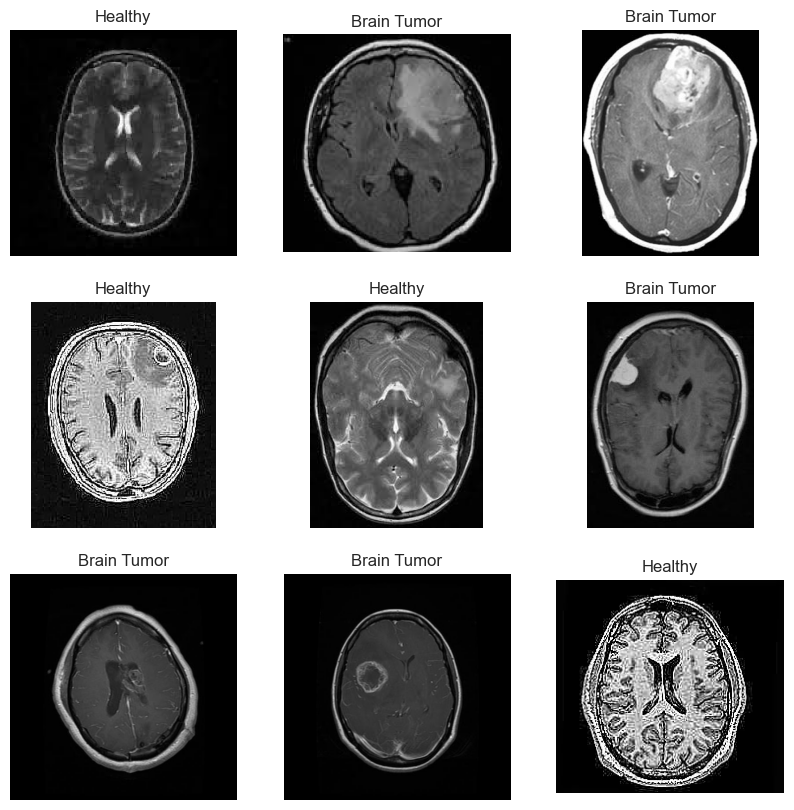

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random
def visualize_images(data_dir, num_images=9):
    categories = [cat for cat in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, cat))]
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    for ax in axes.flat:
        category = random.choice(categories)
        category_path = os.path.join(data_dir, category)
        images = [img for img in os.listdir(category_path) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if images:
            image_path = os.path.join(category_path, random.choice(images))
            img = Image.open(image_path)
            ax.imshow(img)
            ax.set_title(category)
            ax.axis("off")
    plt.show()
visualize_images("C:/Users/sures/Downloads/Brain_Tumor/Brain Tumor Data Set")


Brain_tumor Classifier

Function to Calculate Output Dimensions of a 2D Convolutional Layer

In [18]:
'''This function can be useful in determining the output size of a convolutional layer in a neural network,
given the input dimensions and the convolutional layer's parameters.'''

def findConv2dOutShape(hin,win,conv,pool=2):
    # get conv arguments
    kernel_size = conv.kernel_size
    stride=conv.stride
    padding=conv.padding
    dilation=conv.dilation
    hout=np.floor((hin+2*padding[0]-dilation[0]*(kernel_size[0]-1)-1)/stride[0]+1)
    wout=np.floor((win+2*padding[1]-dilation[1]*(kernel_size[1]-1)-1)/stride[1]+1)
    if pool:
        hout/=pool
        wout/=pool
    return int(hout),int(wout)

CNN_TUMOR: Convolutional Neural Network Architecture for Brain Tumor Detection

In [19]:
# Define Architecture For CNN_TUMOR Model
class CNN_TUMOR(nn.Module):
    # Network Initialisation
    def __init__(self, params):
        super(CNN_TUMOR, self).__init__()
        Cin,Hin,Win = params["shape_in"]
        init_f = params["initial_filters"] 
        num_fc1 = params["num_fc1"]  
        num_classes = params["num_classes"] 
        self.dropout_rate = params["dropout_rate"] 
        # Convolution Layers
        self.conv1 = nn.Conv2d(Cin, init_f, kernel_size=3)
        h,w=findConv2dOutShape(Hin,Win,self.conv1)
        self.conv2 = nn.Conv2d(init_f, 2*init_f, kernel_size=3)
        h,w=findConv2dOutShape(h,w,self.conv2)
        self.conv3 = nn.Conv2d(2*init_f, 4*init_f, kernel_size=3)
        h,w=findConv2dOutShape(h,w,self.conv3)
        self.conv4 = nn.Conv2d(4*init_f, 8*init_f, kernel_size=3)
        h,w=findConv2dOutShape(h,w,self.conv4)
        # compute the flatten size
        self.num_flatten=h*w*8*init_f
        self.fc1 = nn.Linear(self.num_flatten, num_fc1)
        self.fc2 = nn.Linear(num_fc1, num_classes)
    def forward(self,X):
        # Convolution & Pool Layers
        X = F.relu(self.conv1(X)); 
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv3(X))
        X = F.max_pool2d(X, 2, 2)
        X = F.relu(self.conv4(X))
        X = F.max_pool2d(X, 2, 2)
        X = X.view(-1, self.num_flatten)
        X = F.relu(self.fc1(X))
        X = F.dropout(X, self.dropout_rate)
        X = self.fc2(X)
        return F.log_softmax(X, dim=1)

Initializing and Configuring CNN_TUMOR Model for Training

In [20]:
params_model={
        "shape_in": (3,256,256), 
        "initial_filters": 8,    
        "num_fc1": 100,
        "dropout_rate": 0.25,
        "num_classes": 2}
# Create instantiation of Network class
cnn_model = CNN_TUMOR(params_model)
# define computation hardware approach (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = cnn_model.to(device)

In [21]:
# Model Summary for CNN Model
summary(cnn_model, input_size=(3, 256, 256),device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 254, 254]             224
            Conv2d-2         [-1, 16, 125, 125]           1,168
            Conv2d-3           [-1, 32, 60, 60]           4,640
            Conv2d-4           [-1, 64, 28, 28]          18,496
            Linear-5                  [-1, 100]       1,254,500
            Linear-6                    [-1, 2]             202
Total params: 1,279,230
Trainable params: 1,279,230
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.75
Forward/backward pass size (MB): 7.11
Params size (MB): 4.88
Estimated Total Size (MB): 12.74
----------------------------------------------------------------


Loss Function Definition

In [22]:
loss_func = nn.NLLLoss(reduction="sum")

Optimiser Definition

In [23]:
opt = optim.Adam(cnn_model.parameters(), lr=3e-4)
lr_scheduler = ReduceLROnPlateau(opt, mode='min',factor=0.5, patience=20,verbose=1)

Training Model

In [24]:
# Function to get the learning rate
def get_lr(opt):
    for param_group in opt.param_groups:
        return param_group['lr']
# Function to compute the loss value per batch of data
def loss_batch(loss_func, output, target, opt=None):
    loss = loss_func(output, target) # get loss
    pred = output.argmax(dim=1, keepdim=True) # Get Output Class
    metric_b=pred.eq(target.view_as(pred)).sum().item() # get performance metric
    if opt is not None:
        opt.zero_grad()
        loss.backward()
        opt.step()
    return loss.item(), metric_b
# Compute the loss value & performance metric for the entire dataset (epoch)
def loss_epoch(model,loss_func,dataset_dl,opt=None):
    run_loss=0.0 
    t_metric=0.0
    len_data=len(dataset_dl.dataset)
    # internal loop over dataset
    for xb, yb in dataset_dl:
        # move batch to device
        xb=xb.to(device)
        yb=yb.to(device)
        output=model(xb) # get model output
        loss_b,metric_b=loss_batch(loss_func, output, yb, opt) # get loss per batch
        run_loss+=loss_b        # update running loss
        if metric_b is not None: # update running metric
            t_metric+=metric_b    
    loss=run_loss/float(len_data)  # average loss value
    metric=t_metric/float(len_data) # average metric value
    return loss, metric

Training Function

In [25]:
def Train_Val(model, params,verbose=False):
    # Get the parameters
    epochs=params["epochs"]
    loss_func=params["f_loss"]
    opt=params["optimiser"]
    train_dl=params["train"]
    val_dl=params["val"]
    lr_scheduler=params["lr_change"]
    weight_path=params["weight_path"]
    # history of loss values in each epoch
    loss_history={"train": [],"val": []} 
    # histroy of metric values in each epoch
    metric_history={"train": [],"val": []} 
    # a deep copy of weights for the best performing model
    best_model_wts = copy.deepcopy(model.state_dict()) 
    # initialize best loss to a large value
    best_loss=float('inf') 
# Train Model n_epochs
    for epoch in tqdm(range(epochs)):
        # Get the Learning Rate
        current_lr=get_lr(opt)
        if(verbose):
            print('Epoch {}/{}, current lr={}'.format(epoch, epochs - 1, current_lr))
# Train Model Process
        model.train()
        train_loss, train_metric = loss_epoch(model,loss_func,train_dl,opt)
        # collect losses
        loss_history["train"].append(train_loss)
        metric_history["train"].append(train_metric)
# Evaluate Model Process
        model.eval()
        with torch.no_grad():
            val_loss, val_metric = loss_epoch(model,loss_func,val_dl)
        # store best model
        if(val_loss < best_loss):
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            # store weights into a local file
            torch.save(model.state_dict(), weight_path)
            if(verbose):
                print("Copied best model weights!")
        # collect loss and metric for validation dataset
        loss_history["val"].append(val_loss)
        metric_history["val"].append(val_metric)
        # learning rate schedule
        lr_scheduler.step(val_loss)
        if current_lr != get_lr(opt):
            if(verbose):
                print("Loading best model weights!")
            model.load_state_dict(best_model_wts) 
        if(verbose):
            print(f"train loss: {train_loss:.6f}, dev loss: {val_loss:.6f}, accuracy: {100*val_metric:.2f}")
            print("-"*10) 
    # load best model weights
    model.load_state_dict(best_model_wts)
    return model, loss_history, metric_history

Training Process

In [26]:
# Define various parameters used for training and evaluation of a cnn_model
params_train={
 "train": train_loader,"val": val_loader,
 "epochs": 60,
 "optimiser": optim.Adam(cnn_model.parameters(),lr=3e-4),
 "lr_change": ReduceLROnPlateau(opt,
                                mode='min',
                                factor=0.5,
                                patience=20,
                                verbose=0),
 "f_loss": nn.NLLLoss(reduction="sum"),
 "weight_path": "weights.pt",
}
# train and validate the model
cnn_model,loss_hist,metric_hist = Train_Val(cnn_model,params_train)

  0%|          | 0/60 [00:00<?, ?it/s]

Evaluation Metric Visualization

<Axes: >

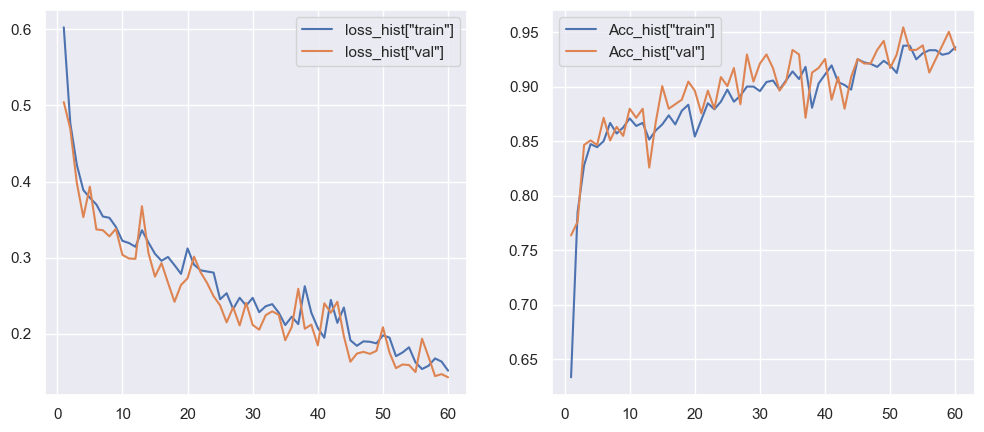

In [27]:
# Convergence History Plot
epochs=params_train["epochs"]
fig,ax = plt.subplots(1,2,figsize=(12,5))
sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["train"],ax=ax[0],label='loss_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=loss_hist["val"],ax=ax[0],label='loss_hist["val"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["train"],ax=ax[1],label='Acc_hist["train"]')
sns.lineplot(x=[*range(1,epochs+1)],y=metric_hist["val"],ax=ax[1],label='Acc_hist["val"]')

Classification Report

In [28]:
# define function For Classification Report
def Ture_and_Pred(val_loader, model):
    i = 0
    y_true = []
    y_pred = []
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.numpy()
        outputs = model(images)
        _, pred = torch.max(outputs.data, 1)
        pred = pred.detach().cpu().numpy()
        
        y_true = np.append(y_true, labels)
        y_pred = np.append(y_pred, pred)
    
    return y_true, y_pred


# check confusion matrix for error analysis
y_true, y_pred = Ture_and_Pred(val_loader, cnn_model)

print(classification_report(y_true, y_pred), '\n\n')
cm = confusion_matrix(y_true, y_pred)

              precision    recall  f1-score   support

         0.0       0.95      0.92      0.94       104
         1.0       0.94      0.96      0.95       137

    accuracy                           0.95       241
   macro avg       0.95      0.94      0.94       241
weighted avg       0.95      0.95      0.95       241
 




Confusion Matrix Plotting Function

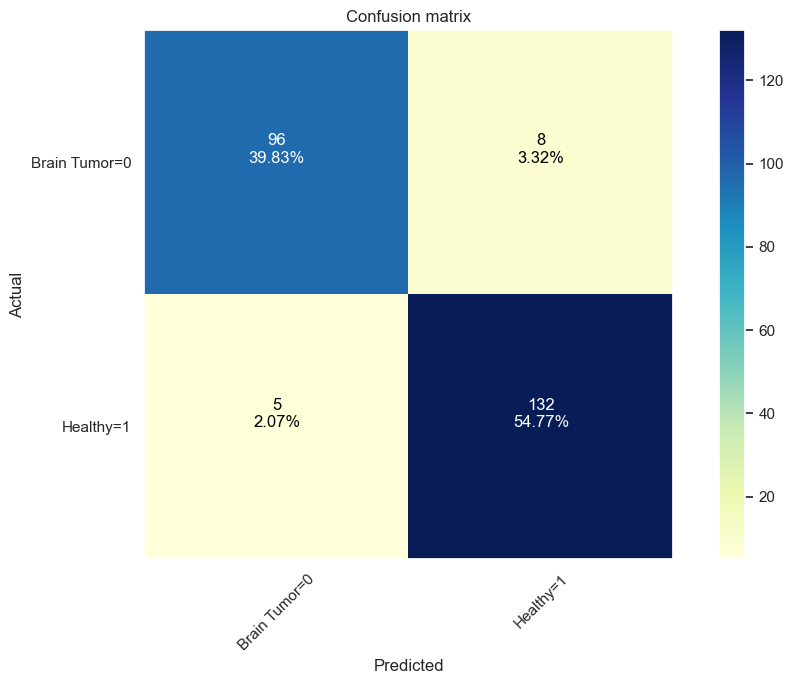

In [29]:
# Confusion Matrix Plotting Function
def show_confusion_matrix(cm, CLA_label, title='Confusion matrix', cmap=plt.cm.YlGnBu):
    
    plt.figure(figsize=(10,7))
    plt.grid(False)
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(CLA_label))

    plt.xticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()], rotation=45)
    plt.yticks(tick_marks, [f"{value}={key}" for key , value in CLA_label.items()])

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f"{cm[i,j]}\n{cm[i,j]/np.sum(cm)*100:.2f}%", horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

show_confusion_matrix(cm, CLA_label)

Save Model

In [30]:
torch.save(cnn_model, "Brain_Tumor_model.pt")

Testing New Data

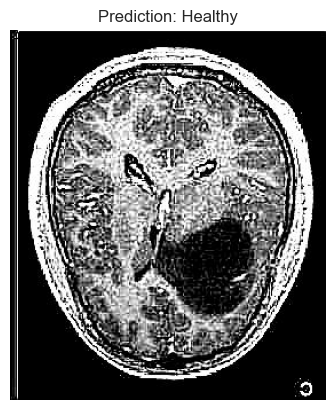

Prediction: Healthy


In [31]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

# Define the prediction function
def predict_image(image_path, model):
    """Predicts if the image has a brain tumor or is healthy and displays the image."""
    image = Image.open(image_path).convert("RGB")  # Ensure 3-channel image
    transformed_image = transform(image).unsqueeze(0)  # Add batch dimension

    with torch.no_grad():
        output = model(transformed_image)
        _, predicted = torch.max(output, 1)  # Get predicted class

    labels = {0: "Brain Tumor", 1: "Healthy"}
    prediction = labels[predicted.item()]

    # Display the image with prediction
    plt.imshow(image)
    plt.title(f"Prediction: {prediction}")
    plt.axis('off')
    plt.show()

    return prediction

# Test with an image
image_path = "C:/Users/sures/Downloads/Brain_Tumor/test_data3.jpg"  
result = predict_image(image_path, model)
print(f"Prediction: {result}")

Long Short-Term Memory(LSTM)Model for Brain Tumor Detection

Importing Essential Libraries

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_curve, auc
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

Device & Transforms

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

Dataset Paths

In [34]:
base_path = Path("C:/Users/sures/Downloads/Brain_Tumor/brain")
train_ds = datasets.ImageFolder(str(base_path/'train'), transform=transform)
val_ds = datasets.ImageFolder(str(base_path/'val'), transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
class_names = train_ds.classes  # ['no', 'yes']


LSTM Model Definition

In [35]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=192, hidden_size=128, num_layers=2, num_classes=2):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size * 64, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), x.size(3), -1)  # [batch, width=64, height*channels=192]
        out, _ = self.lstm(x)
        out = out.contiguous().view(out.size(0), -1)
        out = self.fc(out)
        return out

model = LSTMClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training Function

In [36]:
def train_model(epochs=20):
    train_acc, val_acc = [], []

    for epoch in range(epochs):
        model.train()
        correct_train = total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs.data, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_accuracy = 100 * correct_train / total_train
        train_acc.append(train_accuracy)

        # Validation
        model.eval()
        correct_val = total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val
        val_acc.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%")

    return train_acc, val_acc
# Train the Model
train_acc, val_acc = train_model(epochs=20)

Epoch [1/20], Train Acc: 65.28%, Val Acc: 77.18%
Epoch [2/20], Train Acc: 75.28%, Val Acc: 78.01%
Epoch [3/20], Train Acc: 79.31%, Val Acc: 83.82%
Epoch [4/20], Train Acc: 81.94%, Val Acc: 80.91%
Epoch [5/20], Train Acc: 85.14%, Val Acc: 86.72%
Epoch [6/20], Train Acc: 86.25%, Val Acc: 89.63%
Epoch [7/20], Train Acc: 90.56%, Val Acc: 88.80%
Epoch [8/20], Train Acc: 89.86%, Val Acc: 91.70%
Epoch [9/20], Train Acc: 92.22%, Val Acc: 92.53%
Epoch [10/20], Train Acc: 95.00%, Val Acc: 94.61%
Epoch [11/20], Train Acc: 93.89%, Val Acc: 95.85%
Epoch [12/20], Train Acc: 95.28%, Val Acc: 96.68%
Epoch [13/20], Train Acc: 96.67%, Val Acc: 92.12%
Epoch [14/20], Train Acc: 95.00%, Val Acc: 95.85%
Epoch [15/20], Train Acc: 96.81%, Val Acc: 95.85%
Epoch [16/20], Train Acc: 96.25%, Val Acc: 95.85%
Epoch [17/20], Train Acc: 96.11%, Val Acc: 96.68%
Epoch [18/20], Train Acc: 98.47%, Val Acc: 97.51%
Epoch [19/20], Train Acc: 97.78%, Val Acc: 98.76%
Epoch [20/20], Train Acc: 98.75%, Val Acc: 98.34%


Accuracy Plot

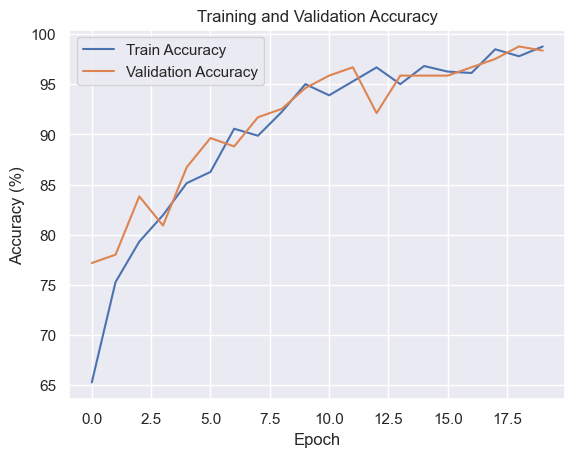

In [37]:
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Evaluation: Classification Report & ROC Curve

Classification Report:

              precision    recall  f1-score   support

 Brain Tumor       0.98      0.98      0.98       104
     Healthy       0.99      0.99      0.99       137

    accuracy                           0.98       241
   macro avg       0.98      0.98      0.98       241
weighted avg       0.98      0.98      0.98       241



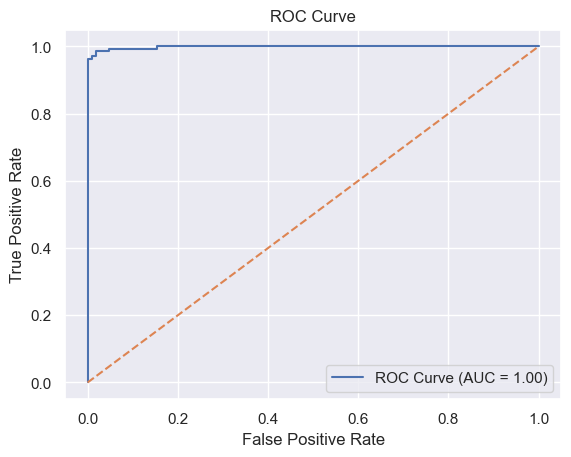

In [38]:
def evaluate_model():
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

evaluate_model()


Plot Confusion Matrix

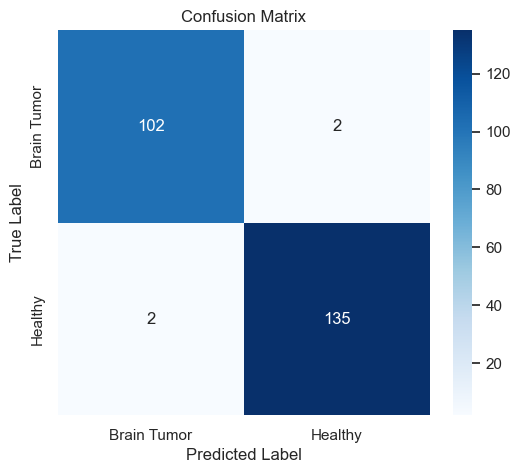

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def plot_confusion_matrix():
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
plot_confusion_matrix()


Predicting New Data

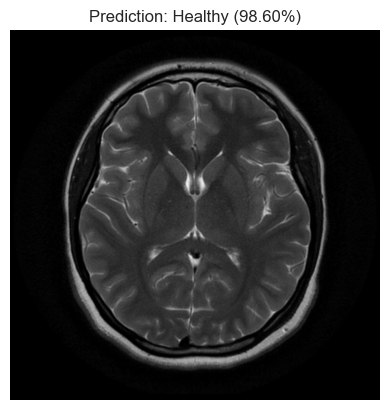

('Healthy', 0.9859747290611267)

In [40]:
def predict_image(image_path):
    model.eval()
    
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_transformed = transform(img).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(img_transformed)
        probs = torch.softmax(output, dim=1)
        _, predicted = torch.max(probs, 1)

    predicted_class = class_names[predicted.item()]
    confidence = probs[0][predicted.item()].item()
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class, confidence
# Path to a new image
new_image_path = "C:/Users/sures/Downloads/Brain_Tumor/test_data5.jpeg"
predict_image(new_image_path)

In [41]:
torch.save(model.state_dict(), "weights.pth")
